# 切口 A · Step 1 — 三层用户的 Day 3-7 衰减分布与假死阈值决策

**目标**:基于 03 notebook 已确认的三层划分(低 ≤ 8 / 中 9-25 / 高 > 25 个 Day 1-2 行为),
分别看每一层在 Day 3-7 的日均行为分布,判断:

1. 每层分布是否"符合该 tier 的自然形态"(sanity check)
2. 若分布合理 → 用低分位数(如 25% 分位)定假死阈值
3. 若分布异常下移 → 标记为系统问题,不在该层做假死细分

**为什么观察期是 Day 3-7 而不是 Day 3-9**:已在 03 notebook 确认 Day 8-9 是双 12 预热,
活跃度被异常拉高,会污染"假死判断"。

**注意**:本 notebook 还不下"最终假死阈值",只给出分析数据让用户决策。


## 0. 环境与数据加载

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 中文显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

PARQUET_PATH = Path('../data/processed/DWD/user_behavior_clean.parquet').resolve()
print(f'DWD 文件: {PARQUET_PATH}')

con = duckdb.connect()
con.execute(f"""
CREATE OR REPLACE VIEW ub AS
SELECT
    user_id, item_id, category_id, behavior_type, timestamp,
    CAST(to_timestamp(timestamp) AS DATE) AS event_date
FROM '{PARQUET_PATH.as_posix()}'
""")
print('视图 ub 已建立')

DWD 文件: D:\IndividualProject\留存分析项目\data\processed\DWD\user_behavior_clean.parquet
视图 ub 已建立


---

## Part 1:构建用户级 cohort 表

每个 C2 cohort 用户(Day 1-2 内有行为的用户),计算:
- `d12_actions`:Day 1-2 总行为数
- `d37_actions`:Day 3-7 总行为数(注意:5 天观察期,排除 Day 8-9 双 12 污染)
- `d12_per_day` / `d37_per_day`:**归一化后**的日均
- `tier`:基于 d12_actions 分层(低 / 中 / 高活跃)

In [2]:
# Part 1.1:从 DuckDB 拉出每个 cohort 用户的两窗口行为数

cohort_df = con.sql("""
WITH cohort AS (
    SELECT DISTINCT user_id
    FROM ub
    WHERE event_date IN (DATE '2017-11-25', DATE '2017-11-26')
),
d12 AS (
    SELECT user_id, COUNT(*) AS d12_actions
    FROM ub
    WHERE event_date IN (DATE '2017-11-25', DATE '2017-11-26')
    GROUP BY user_id
),
d37 AS (
    SELECT user_id, COUNT(*) AS d37_actions
    FROM ub
    WHERE event_date BETWEEN DATE '2017-11-27' AND DATE '2017-12-01'
    GROUP BY user_id
)
SELECT
    c.user_id,
    d12.d12_actions,
    COALESCE(d37.d37_actions, 0)         AS d37_actions,
    d12.d12_actions / 2.0                AS d12_per_day,
    COALESCE(d37.d37_actions, 0) / 5.0   AS d37_per_day
FROM cohort c
LEFT JOIN d12 ON c.user_id = d12.user_id
LEFT JOIN d37 ON c.user_id = d37.user_id
""").df()

print(f'用户总数: {len(cohort_df):,}')
print()
print('前 5 行预览:')
print(cohort_df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

用户总数: 864,829

前 5 行预览:
   user_id  d12_actions  d37_actions  d12_per_day  d37_per_day
0   161818           21           23         10.5          4.6
1   161876           12          116          6.0         23.2
2   162077            8           20          4.0          4.0
3   162107           15           45          7.5          9.0
4   162274            7           16          3.5          3.2


In [3]:
# Part 1.2:基于 d12_actions 分三层(沿用 03 notebook 的 8 / 25 阈值)

cohort_df['tier'] = pd.cut(
    cohort_df['d12_actions'],
    bins=[0, 8, 25, float('inf')],
    labels=['低活跃', '中活跃', '高活跃']
)

tier_summary = cohort_df.groupby('tier', observed=True).size().reset_index(name='users')
tier_summary['pct'] = (tier_summary['users'] / tier_summary['users'].sum() * 100).round(2)
print('三层占比:')
print(tier_summary)

三层占比:
  tier   users    pct
0  低活跃  305242  35.30
1  中活跃  280316  32.41
2  高活跃  279271  32.29


---

## Part 2:每层 Day 3-7 日均行为数的分位数表

核心一张表。看 D3-7 日均的 10% / 25% / 50% / 75% / 90% 分位,**与 D1-2 日均基线对照**。

In [4]:
# Part 2.1:每层分位数表(D3-7 日均)
quantile_table = cohort_df.groupby('tier', observed=True)['d37_per_day'].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]
).round(2)

# 把 d12_per_day 也按 tier 算 mean 拼进来,作为基线参照
baseline = cohort_df.groupby('tier', observed=True)['d12_per_day'].mean().round(2)
quantile_table.insert(0, 'd12_per_day_mean', baseline)

print('每层 D3-7 日均行为数分位数(与 D1-2 日均均值对照):')
print(quantile_table)

每层 D3-7 日均行为数分位数(与 D1-2 日均均值对照):
      d12_per_day_mean     count   mean    std  min  10%  25%   50%   75%  \
tier                                                                        
低活跃               1.94  305242.0   6.65   7.53  0.0  0.6  1.8   4.2   8.8   
中活跃               7.88  280316.0   9.89   9.34  0.0  1.4  3.4   7.2  13.4   
高活跃              27.72  279271.0  16.77  13.12  0.0  3.4  7.2  13.6  23.0   

       90%    max  
tier               
低活跃   15.6  122.2  
中活跃   21.6  120.4  
高活跃   34.4  127.4  


**怎么读这张表**:

- `d12_per_day_mean`:该层用户在 Day 1-2 的**日均基线**(平均水平)
- 后面几列:该层在 Day 3-7 的日均**分位数**
- **判断方法**:对比基线和 50%(中位数)
  - 如果中位数 ≈ 基线:整层活跃度持平,**分布合理**
  - 如果中位数 << 基线:整层下移,**异常**(系统问题信号)
  - 如果某个低分位(10% / 25%)非常低:那部分就是假死候选

---

## Part 3:每层 D3-7 日均直方图(看分布形态)

C:\Users\33238\AppData\Local\Temp\ipykernel_103120\1388072446.py:26: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_103120\1388072446.py:26: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_103120\1388072446.py:26: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_103120\1388072446.py:26: UserWarning: Glyph 20026 (\N{CJK UNIFIED IDEOGRAPH-4E3A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_103120\1388072446.py:26: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_103120\1388072446.py:26: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-

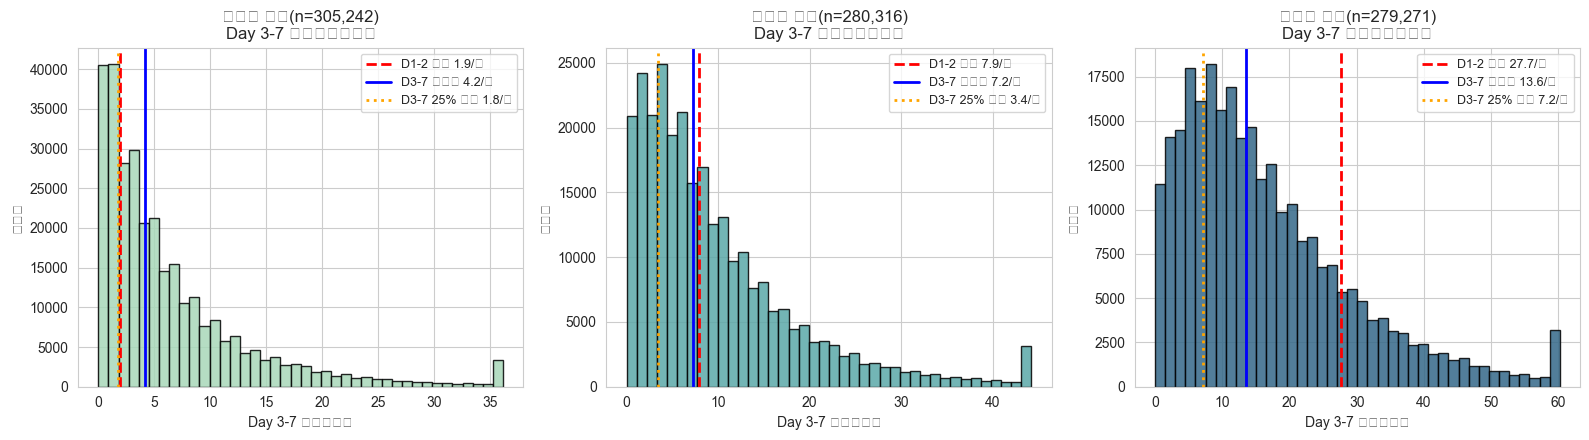

In [5]:
# 三张直方图并排
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
tier_colors = {'低活跃': '#A8D8B9', '中活跃': '#5BA8A8', '高活跃': '#346888'}

for ax, tier in zip(axes, ['低活跃', '中活跃', '高活跃']):
    sub = cohort_df[cohort_df['tier'] == tier]['d37_per_day']
    baseline_mean = cohort_df[cohort_df['tier'] == tier]['d12_per_day'].mean()
    median = sub.median()
    p25 = sub.quantile(0.25)

    # 99% 分位之上的极端值会让直方图不可读,所以截尾
    upper = sub.quantile(0.99)
    sub_clipped = sub.clip(upper=upper)
    ax.hist(sub_clipped, bins=40, color=tier_colors[tier], edgecolor='black', alpha=0.85)

    # 基线、中位数、25% 分位三条线
    ax.axvline(baseline_mean, color='red',   linestyle='--', linewidth=2, label=f'D1-2 基线 {baseline_mean:.1f}/天')
    ax.axvline(median,        color='blue',  linestyle='-',  linewidth=2, label=f'D3-7 中位数 {median:.1f}/天')
    ax.axvline(p25,           color='orange',linestyle=':',  linewidth=2, label=f'D3-7 25% 分位 {p25:.1f}/天')

    ax.set_title(f'{tier} 用户(n={len(sub):,})\nDay 3-7 日均行为数分布')
    ax.set_xlabel('Day 3-7 日均行为数')
    ax.set_ylabel('用户数')
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

**三条参考线的含义**:
- 🔴 红色虚线 = D1-2 基线:该层在 Day 1-2 的日均活跃水平
- 🔵 蓝色实线 = D3-7 中位数:该层在 Day 3-7 的日均"典型水平"
- 🟠 橙色点线 = D3-7 25% 分位:活跃度最低的 25% 用户的边界,**假死阈值候选**

**判断要点**:
- 蓝色离红色多近?越近说明整层"没怎么衰减",分布合理
- 蓝色离红色远(大幅下移)?**异常信号**
- 橙色这条线的位置就是假死阈值的"参考候选"(假死 = D3-7 日均 ≤ 橙色线值)

---

## Part 4:Sanity check 汇总表

把"基线 vs 实际"的对比做成一张干净的表,方便决策。

In [6]:
# Part 4 sanity check
sanity = cohort_df.groupby('tier', observed=True).agg(
    users         = ('user_id',     'count'),
    d12_per_day   = ('d12_per_day', 'mean'),
    d37_per_day   = ('d37_per_day', 'mean'),
    d37_median    = ('d37_per_day', 'median'),
    d37_p25       = ('d37_per_day', lambda s: s.quantile(0.25)),
    d37_p10       = ('d37_per_day', lambda s: s.quantile(0.10)),
).round(2)

# 加一列:整层"平均衰减幅度"
sanity['avg_decay_pct'] = ((1 - sanity['d37_per_day'] / sanity['d12_per_day']) * 100).round(1)

# 加一列:sanity 标签
def sanity_flag(row):
    if row['d37_per_day'] < row['d12_per_day'] * 0.3:
        return '⚠ 整层下移严重(衰减>70%),疑似系统问题'
    elif row['d37_per_day'] < row['d12_per_day'] * 0.5:
        return '⚡ 整层中等下移(衰减 50-70%),边界'
    else:
        return '✓ 分布合理(衰减<50%)'
sanity['sanity'] = sanity.apply(sanity_flag, axis=1)

print('每层 sanity check:')
print(sanity)

每层 sanity check:
       users  d12_per_day  d37_per_day  d37_median  d37_p25  d37_p10  \
tier                                                                   
低活跃   305242         1.94         6.65         4.2      1.8      0.6   
中活跃   280316         7.88         9.89         7.2      3.4      1.4   
高活跃   279271        27.72        16.77        13.6      7.2      3.4   

      avg_decay_pct          sanity  
tier                                 
低活跃          -242.8  ✓ 分布合理(衰减<50%)  
中活跃           -25.5  ✓ 分布合理(衰减<50%)  
高活跃            39.5  ✓ 分布合理(衰减<50%)  


**这张表帮你做决策**:

- `avg_decay_pct`:整层平均衰减百分比。**< 50% 算正常,50-70% 边界,> 70% 异常**
- `sanity` 列直接给出判断
- 对"分布合理"的层 → 可以在 `d37_p25` 或 `d37_p10` 这个值附近定假死阈值
- 对"整层异常"的层 → 不要做假死细分,标记系统问题

---

## Part 5:跨层迁移图(D1-2 tier → D3-7 tier)

如果用 Day 3-7 日均**重新分层**(用同样的 ≤4 / 4-12.5 / >12.5 阈值,且加一个"近假死"层),
看 Day 1-2 的每个 tier 用户在 Day 3-7 落到了哪个 tier。

> **解读关键**:对角线 = "保持原层级"。如果**中活跃用户大批跑到"低活跃"甚至"近假死"那一列**,
> 说明系统性问题(整体活跃度下沉)。如果对角线最浓 + 旁边少数偏移到低层,**符合自然衰减预期**。

跨层迁移矩阵(行=Day 1-2 tier,列=Day 3-7 tier,值=每行占比 %):
d37_tier   近假死    低活跃    中活跃    高活跃
tier                               
低活跃       1.25  47.82  36.15  14.78
中活跃       1.12  28.47  42.95  27.46
高活跃       0.73  12.10  33.40  53.77


c:\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 36817 (\N{CJK UNIFIED IDEOGRAPH-8FD1}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 20551 (\N{CJK UNIFIED IDEOGRAPH-5047}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 27515 (\N{CJK UNIFIED IDEOGRAPH-6B7B}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 27963 (\N{CJK UNIFIED IDEOGRAPH-6D3B}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 36291 (\N{CJK UNIFIED IDEOGRAPH-8DC3}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Python312\Lib\site-packages\seaborn\utils.py:61: 

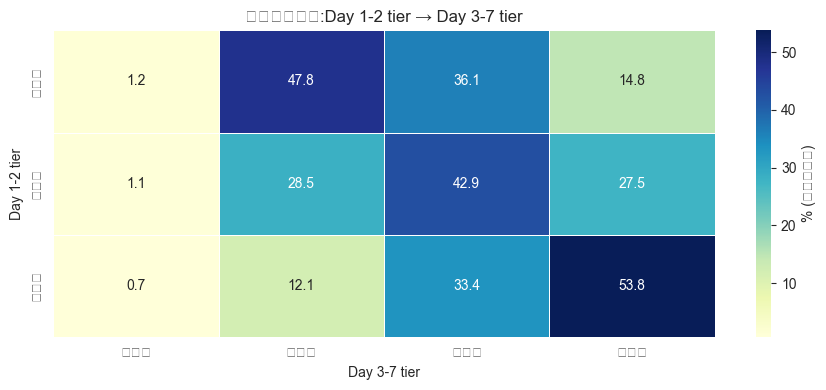

In [7]:
# 用 D3-7 日均重新分层(加一个"近假死"层:日均 < 0.2,即 5 天总共 < 1 次)
def d37_classify(per_day):
    if per_day < 0.2:        return '近假死'
    elif per_day <= 4:       return '低活跃'
    elif per_day <= 12.5:    return '中活跃'
    else:                    return '高活跃'

cohort_df['d37_tier'] = cohort_df['d37_per_day'].apply(d37_classify)

# 跨层迁移矩阵(行归一化,看每个原 tier 流向)
trans_matrix = pd.crosstab(
    cohort_df['tier'],
    cohort_df['d37_tier'],
    normalize='index'
) * 100

# 强制列顺序:从最差到最好
col_order = ['近假死', '低活跃', '中活跃', '高活跃']
trans_matrix = trans_matrix[col_order]

print('跨层迁移矩阵(行=Day 1-2 tier,列=Day 3-7 tier,值=每行占比 %):')
print(trans_matrix.round(2))

# 热力图可视化
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(trans_matrix, annot=True, fmt='.1f', cmap='YlGnBu',
            cbar_kws={'label': '% (按行归一化)'}, linewidths=0.5, ax=ax)
ax.set_title('跨层迁移矩阵:Day 1-2 tier → Day 3-7 tier')
ax.set_xlabel('Day 3-7 tier')
ax.set_ylabel('Day 1-2 tier')
plt.tight_layout()
plt.show()

**怎么读这张矩阵**:

- 每一**行**:原 tier 的用户里,有多少 % 流向了 D3-7 的各个 tier
- **每行加起来 = 100%**
- 关注点:
  1. **对角线**(同 tier 保持):越大说明用户行为稳定
  2. **"近假死"列**:每个 tier 有多少 % 用户掉到近假死。这是该层的"自然流失率"
  3. **"高活跃 → 低活跃"等大跨度迁移**:如果有大批,是个有趣的发现

---

## Part 6:你的决策模板(等填)

跑完上面所有 cell 后,回答以下问题:

### 问题 1:每层 sanity check 结果如何?
> 看 Part 4 的 `sanity` 列:
> - 低活跃层:✓ / ⚡ / ⚠
> - 中活跃层:✓ / ⚡ / ⚠
> - 高活跃层:✓ / ⚡ / ⚠

### 问题 2:跨层迁移有没有让你意外?
> 看 Part 5 矩阵:
> - 三个 tier 的"自然流失率"(对角线 → 近假死)各是多少?
> - 有没有反常迁移?

### 问题 3:每层假死阈值定多少?
> 仅对 sanity 通过的层定:
> - 低活跃层:假死 = D3-7 日均 ≤ ___ (参考 Part 2 的 25% 或 10% 分位)
> - 中活跃层:假死 = D3-7 日均 ≤ ___
> - 高活跃层:假死 = D3-7 日均 ≤ ___

### 跑完之后告诉 AI 三个问题的答案,我们就进入 Step 2:用阈值算出三组假死用户名单 + 画像对比。
